# VT - Vanguard Total World Stock ETF

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib


%matplotlib inline

In [42]:
file_path = "VT_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

# Clustering

#### K-means

0. date formatting

In [43]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
categorized_df

0    2008-07-01
1    2008-07-02
2    2008-07-07
3    2008-07-08
4    2008-07-23
5    2008-07-28
6    2008-08-01
7    2008-08-14
8    2008-08-25
9    2008-09-04
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2124 non-null   datetime64[ns]
 1   Open             2124 non-null   float64       
 2   High             2124 non-null   float64       
 3   Low              2124 non-null   float64       
 4   Close            2124 non-null   float64       
 5   Volume           2124 non-null   int64         
 6   Open_category    2124 non-null   object        
 7   High_category    2124 non-null   object        
 8   Low_ca

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2008-07-01,42.449,42.857,41.2470,42.423,63725,"(41.86, 42.647]","(42.825, 43.611]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
1,2008-07-02,42.802,42.931,41.7990,41.799,86429,"(42.647, 43.434]","(42.825, 43.611]","(41.604, 42.395]","(41.785, 42.578]","(84580.086, 100253.129]"
2,2008-07-07,42.145,42.163,41.3000,41.827,64235,"(41.86, 42.647]","(42.038, 42.825]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
3,2008-07-08,41.574,41.957,40.7580,41.907,62746,"(41.073, 41.86]","(41.251, 42.038]","(40.023, 40.814]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
4,2008-07-23,42.674,42.742,42.2850,42.406,54540,"(42.647, 43.434]","(42.038, 42.825]","(41.604, 42.395]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
...,...,...,...,...,...,...,...,...,...,...,...
2119,2017-11-03,72.460,72.510,72.2400,72.510,716487,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(711501.8, 727174.843]"
2120,2017-11-06,72.460,72.720,72.4400,72.700,498806,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(492079.2, 507752.243]"
2121,2017-11-08,72.550,72.720,72.4347,72.710,354305,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(351021.814, 366694.857]"
2122,2017-11-09,72.220,72.340,71.8500,72.310,1046159,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(1040635.7, 1056308.743]"


1. add features

In [44]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df['Day'] = categorized_df['Date'].dt.day
categorized_df['Day_of_Week'] = categorized_df['Date'].dt.day_name()  # یا .dt.weekday برای مقدار عددی
categorized_df

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week
0,2008-07-01,42.449,42.857,41.2470,42.423,63725,"(41.86, 42.647]","(42.825, 43.611]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7,1,Tuesday
1,2008-07-02,42.802,42.931,41.7990,41.799,86429,"(42.647, 43.434]","(42.825, 43.611]","(41.604, 42.395]","(41.785, 42.578]","(84580.086, 100253.129]",2008,7,2,Wednesday
2,2008-07-07,42.145,42.163,41.3000,41.827,64235,"(41.86, 42.647]","(42.038, 42.825]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7,7,Monday
3,2008-07-08,41.574,41.957,40.7580,41.907,62746,"(41.073, 41.86]","(41.251, 42.038]","(40.023, 40.814]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7,8,Tuesday
4,2008-07-23,42.674,42.742,42.2850,42.406,54540,"(42.647, 43.434]","(42.038, 42.825]","(41.604, 42.395]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7,23,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119,2017-11-03,72.460,72.510,72.2400,72.510,716487,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(711501.8, 727174.843]",2017,11,3,Friday
2120,2017-11-06,72.460,72.720,72.4400,72.700,498806,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(492079.2, 507752.243]",2017,11,6,Monday
2121,2017-11-08,72.550,72.720,72.4347,72.710,354305,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(351021.814, 366694.857]",2017,11,8,Wednesday
2122,2017-11-09,72.220,72.340,71.8500,72.310,1046159,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(1040635.7, 1056308.743]",2017,11,9,Thursday


2. Feature normalization

In [45]:
# Select features for clustering
features = ['Volume', 'High', 'Low', 'Month', 'Day']
data_for_clustering = categorized_df[features]

# Data normalization
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data_for_clustering)


3. Selecting the number of clusters</br>
To select the optimal number of clusters, use the Elbow Method:

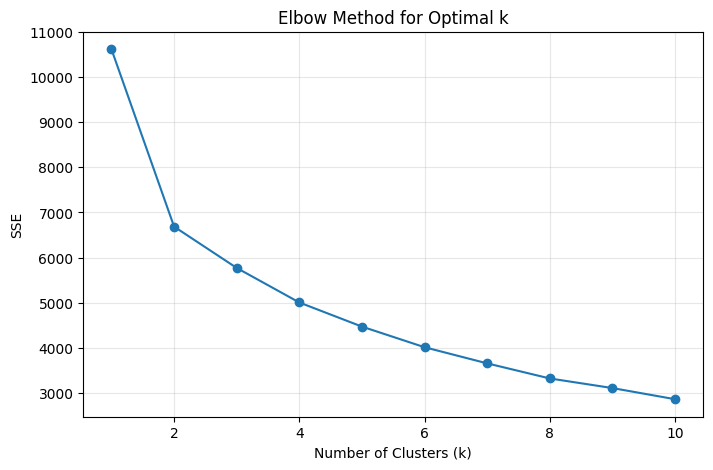

In [46]:
# Calculate SSE for different values of k
sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)  # Explicitly set n_init=10
    kmeans.fit(normalized_data)
    sse.append(kmeans.inertia_)

# Draw Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# The optimal number of clusters is at the point where the graph has a significant change (skeletal).


Clustering with K-Means

just doing it for being sure if the data were too sensitive

In [47]:
# K-Means with optimal number of clusters (k=3)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
categorized_df['Cluster3'] = kmeans.fit_predict(normalized_data)

# Check cluster assignments
print(categorized_df['Cluster3'].value_counts())


Cluster3
1    950
0    613
2    561
Name: count, dtype: int64


the good option here, notitably to the diagram, is k=2

In [48]:
# K-Means with optimal number of clusters (k=2)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
categorized_df['Cluster'] = kmeans.fit_predict(normalized_data)

# Check cluster assignments
print(categorized_df['Cluster'].value_counts())


Cluster
0    1126
1     998
Name: count, dtype: int64


Clustering Visualization

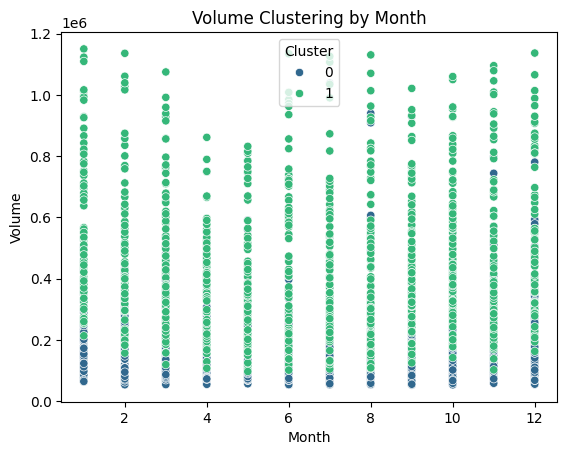

In [49]:
sns.scatterplot(
    x='Month', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Month")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

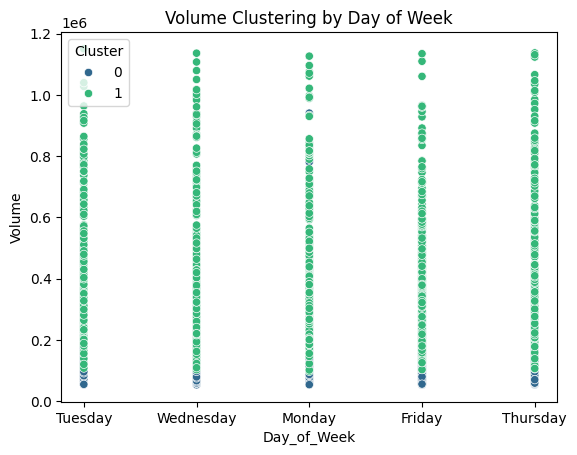

In [50]:
sns.scatterplot(
    x='Day_of_Week', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Day of Week")
plt.xlabel("Day_of_Week")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

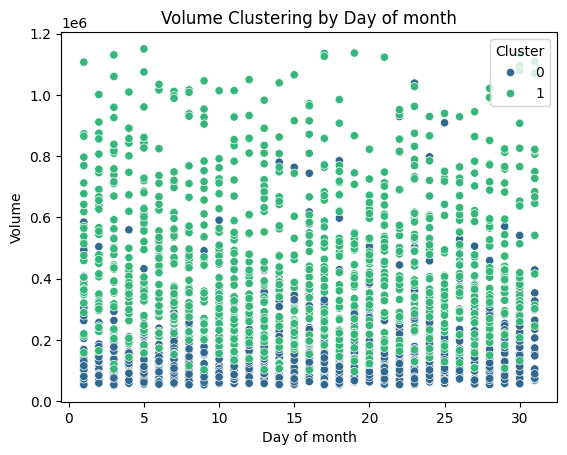

In [51]:
sns.scatterplot(
    x='Day', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Day of month")
plt.xlabel("Day of month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

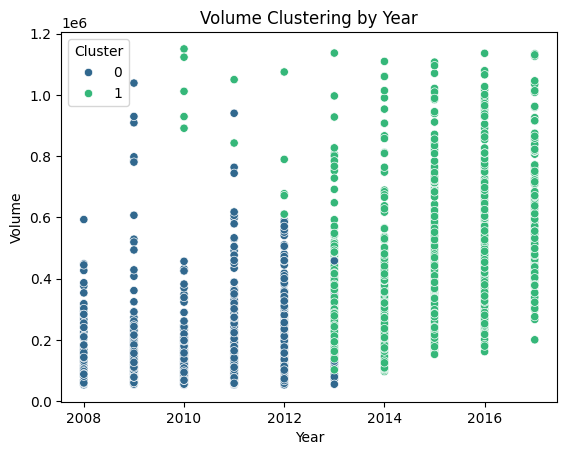

In [52]:
sns.scatterplot(
    x='Year', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

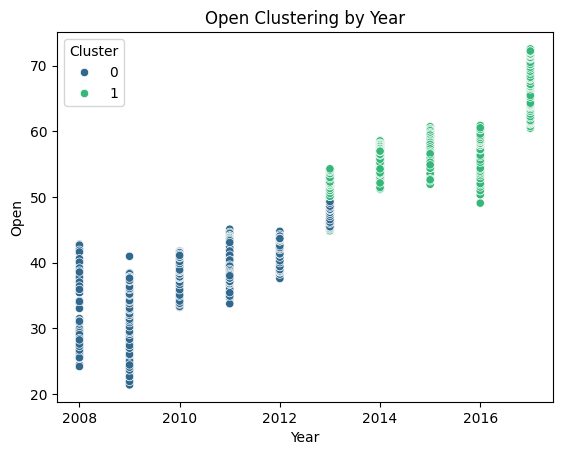

In [53]:
sns.scatterplot(
    x='Year', y='Open', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Open Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Open")
plt.legend(title="Cluster")
plt.show()

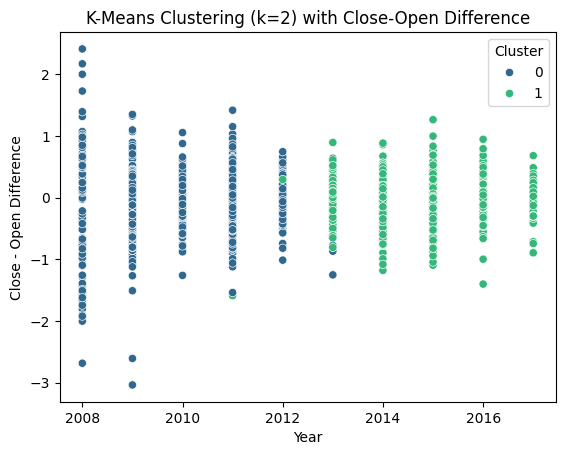

In [54]:
# Create a new column for the difference between Close and Open
categorized_df['Close_Open_Diff'] = categorized_df['Close'] - categorized_df['Open']

# Scatter plot with the difference as y-axis
sns.scatterplot(
    x='Year', y='Close_Open_Diff', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("K-Means Clustering (k=2) with Close-Open Difference")
plt.xlabel("Year")
plt.ylabel("Close - Open Difference")
plt.legend(title="Cluster")
plt.show()


تحلیل زمانی خوشه‌ها

Examining seasonal patterns </br>
breaking down clusters by month, day of the week, or year

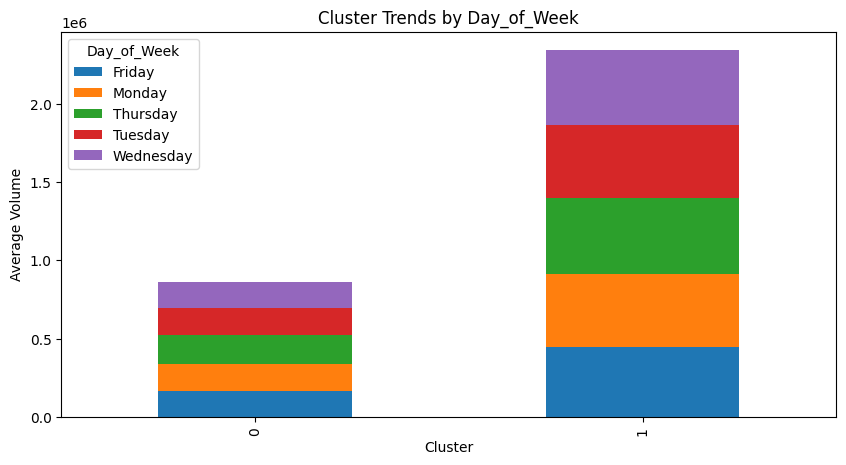

In [55]:
cluster_trends = categorized_df.groupby(['Cluster', 'Day_of_Week'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Day_of_Week")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


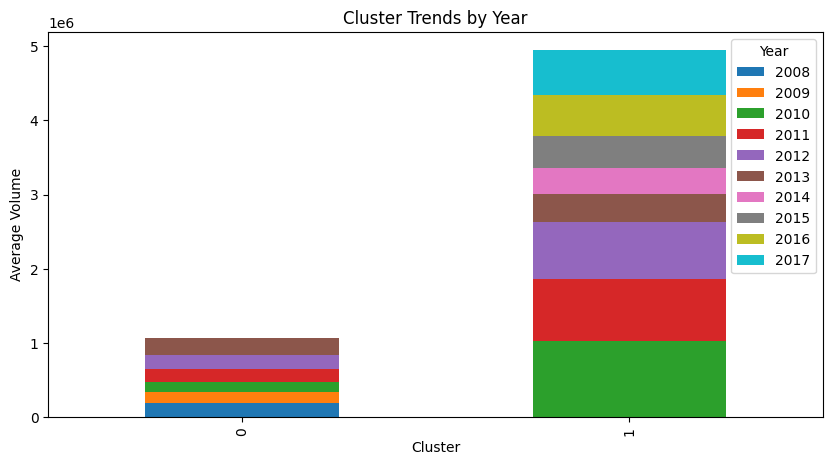

In [56]:
cluster_trends = categorized_df.groupby(['Cluster', 'Year'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Year")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


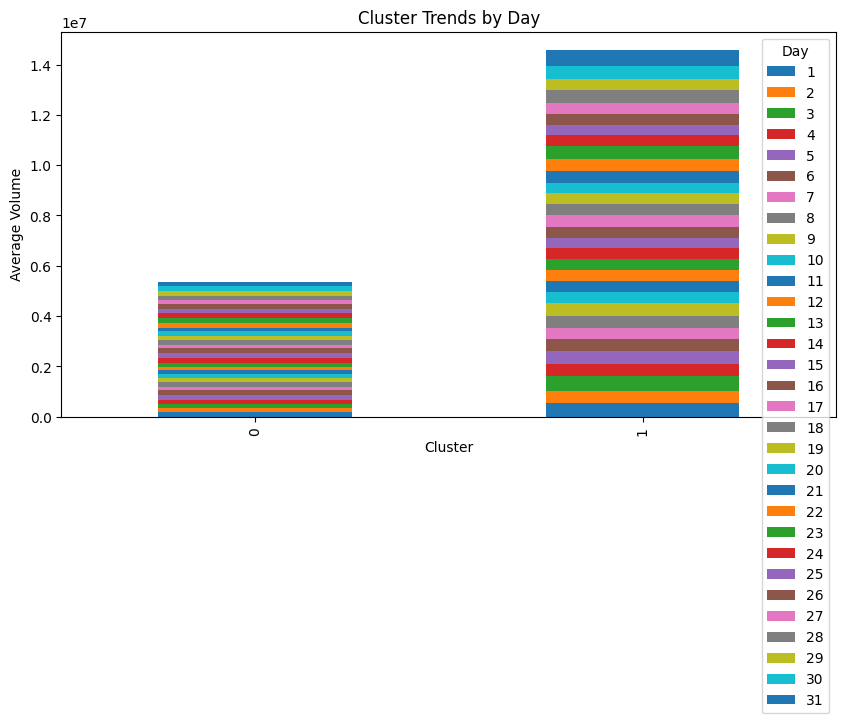

In [57]:
cluster_trends = categorized_df.groupby(['Cluster', 'Day'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Day")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


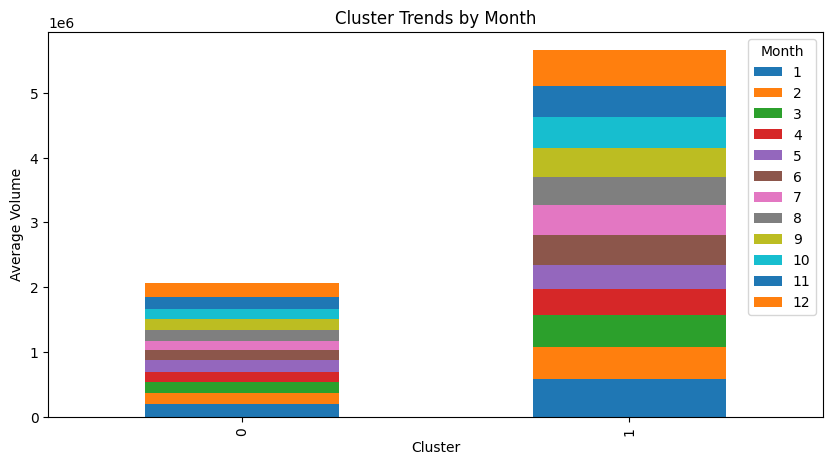

In [58]:
cluster_trends = categorized_df.groupby(['Cluster', 'Month'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Month")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()
